         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

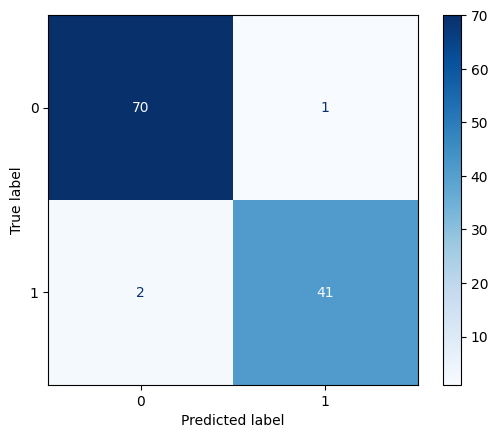

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC AUC: 0.99737962659679


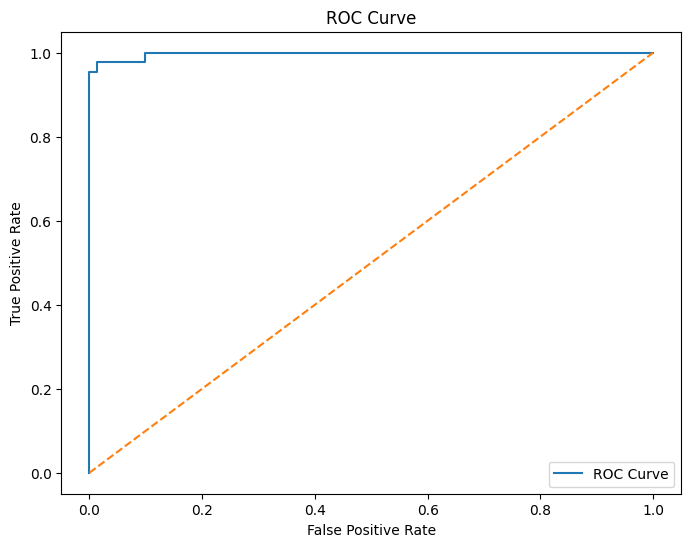

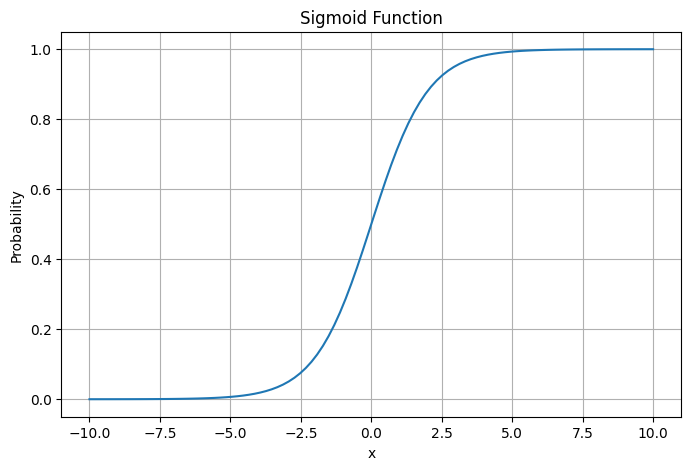

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

#Load Dataset
df = pd.read_csv("data.csv")

#Explore Dataset
print(df.head())

print(df.shape)

print(df.info())

print(df.isnull().sum())

#Data Cleaning
# Remove unnecessary columns

df.drop(columns=["id","Unnamed: 32"], inplace=True)

# Convert diagnosis to numbers

df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

print(df.head())

print(df.isnull().sum())

#Split Features and Target
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

#Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

#Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()

#Classification Report
print(classification_report(y_test,y_pred))

#ROC AUC
roc = roc_auc_score(y_test,y_prob)

print("ROC AUC:",roc)

#ROC Curve
fpr,tpr,threshold = roc_curve(y_test,y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label="ROC Curve")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

#Sigmoid Function
x=np.linspace(-10,10,100)

y=1/(1+np.exp(-x))

plt.figure(figsize=(8,5))

plt.plot(x,y)

plt.title("Sigmoid Function")

plt.xlabel("x")

plt.ylabel("Probability")

plt.grid()

plt.show()